In [15]:
"""Limpieza de mediciones de un péndulo y exportación para Fortran.

Por favor complete los tres bloques marcados como TODO.
"""

from pathlib import Path

import pandas as pd


ARCHIVO_ENTRADA = Path("100_mediciones_pendulo_minimos_cuadrados.xlsx")
HOJA = "Datos_estudiantes"

if not ARCHIVO_ENTRADA.exists():
    raise FileNotFoundError(
        f"No se encontró {ARCHIVO_ENTRADA}. "
        "Guarde el script y el archivo de Excel en la misma carpeta."
    )

datos = pd.read_excel(ARCHIVO_ENTRADA, sheet_name=HOJA)

columnas_requeridas = [
    "medicion_id",
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
    "observador",
    "observacion_campo",
    "calidad_video",
]

columnas_ausentes = [
    columna for columna in columnas_requeridas if columna not in datos.columns
]

if columnas_ausentes:
    raise ValueError(
        "Faltan columnas obligatorias en el archivo: "
        + ", ".join(columnas_ausentes)
    )

# Se conserva una copia independiente de los datos originales.
datos_originales = datos.copy(deep=True)

print("\nNúmero inicial de registros:", len(datos))
print("\nPrimeras mediciones:")
print(datos.head())

datos["incluir"] = True
datos["accion_limpieza"] = "Conservar"
datos["justificacion"] = "Medición aceptada"


def excluir_registros(condicion, justificacion):
    """Excluye únicamente registros que todavía estaban aceptados."""
    nuevos = condicion.fillna(False) & datos["incluir"]
    datos.loc[nuevos, "incluir"] = False
    datos.loc[nuevos, "accion_limpieza"] = "Excluir"
    datos.loc[nuevos, "justificacion"] = justificacion



correcciones_longitud = {
    52: 70.0  # El registro original dice 700 cm (error de tipeo evidente).
}

correcciones_tiempo = {
    23: 19.06,  # Se registró 1.906s (el periodo de 1 oscilación). Para 10 oscilaciones es 19.06s.
    81: 18.53   # Se registró 1.853s. Para 10 oscilaciones es 18.53s.
}

for medicion_id, valor in correcciones_longitud.items():
    condicion = datos["medicion_id"] == medicion_id

    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue

    datos.loc[condicion, "longitud_cm"] = valor
    datos.loc[condicion, "accion_limpieza"] = "Corregir longitud"
    datos.loc[condicion, "justificacion"] = (
        "Error de registro identificado y corregido"
    )

for medicion_id, valor in correcciones_tiempo.items():
    condicion = datos["medicion_id"] == medicion_id

    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue

    datos.loc[condicion, "tiempo_medido_s"] = valor
    datos.loc[condicion, "accion_limpieza"] = "Corregir tiempo"
    datos.loc[condicion, "justificacion"] = (
        "El valor registrado no correspondía al tiempo total"
    )

excluir_registros(
    datos["tiempo_medido_s"].isna(),
    "No existe un tiempo medido",
)

excluir_registros(
    datos["numero_oscilaciones"].isna()
    | (datos["numero_oscilaciones"] <= 0),
    "Número de oscilaciones ausente o no positivo",
)



ANGULO_MAXIMO = 15.0  # Límite estándar para la aproximación de ángulos pequeños.

if ANGULO_MAXIMO is None:
    raise ValueError(

    )


excluir_registros(
    datos["angulo_inicial_deg"].isna()
    | (datos["angulo_inicial_deg"].abs() > ANGULO_MAXIMO),
    "Fuera de la aproximación de ángulo pequeño",
)


# ============================================================
# 6. BÚSQUEDA DE REGISTROS DUPLICADOS
# ============================================================

variables_experimentales = [
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
    "observador",
]


duplicados = pd.Series(False, index=datos.index)
indices_aceptados = datos.index[datos["incluir"]]
duplicados.loc[indices_aceptados] = datos.loc[
    indices_aceptados
].duplicated(subset=variables_experimentales, keep="first")

excluir_registros(
    duplicados,
    "Registro experimental duplicado",
)




# El período se calcula después de aplicar las correcciones.
datos["periodo_preliminar_s"] = (
    datos["tiempo_medido_s"] / datos["numero_oscilaciones"]
)

print("\nLongitudes potencialmente sospechosas:")
print(
    datos.loc[
        (datos["longitud_cm"] < 20) | (datos["longitud_cm"] > 100),
        ["medicion_id", "longitud_cm", "observacion_campo"],
    ]
)

print("\nPeríodos potencialmente sospechosos:")
print(
    datos.loc[
        (datos["periodo_preliminar_s"] < 0.5)
        | (datos["periodo_preliminar_s"] > 3.0),
        [
            "medicion_id",
            "longitud_cm",
            "numero_oscilaciones",
            "tiempo_medido_s",
            "periodo_preliminar_s",
            "observacion_campo",
        ],
    ]
)

print("\nMediciones con calidad de video baja:")
print(
    datos.loc[
        datos["calidad_video"].eq("Baja"),
        ["medicion_id", "calidad_video", "observacion_campo"],
    ]
)




exclusiones_manuales = {
    12: "Archivo de video no disponible",
    36: "Se perdió temporalmente el marcador en el video",
    45: "El cronómetro pareció iniciar tarde",
    68: "Celda sin registrar en la libreta",
    77: "Se perdió temporalmente el marcador en el video",
    88: "No quedó claro si se contaron 5 o 10 oscilaciones"
}
for medicion_id, razon in exclusiones_manuales.items():
    condicion = datos["medicion_id"] == medicion_id

    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue

    datos.loc[condicion, "incluir"] = False
    datos.loc[condicion, "accion_limpieza"] = "Excluir"
    datos.loc[condicion, "justificacion"] = razon




datos_limpios = datos.loc[datos["incluir"]].copy()

print("\nNúmero de registros originales:", len(datos_originales))
print("Número de registros aceptados:", len(datos_limpios))
print("Número de registros excluidos:", len(datos) - len(datos_limpios))




columnas_fortran = [
    "medicion_id",
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
]

datos_limpios[columnas_fortran].to_csv(
    "pendulo_limpio.dat",
    sep=" ",
    index=False,
    header=False,
    float_format="%.6f",
)


columnas_informe = [
    "medicion_id",
    "incluir",
    "accion_limpieza",
    "justificacion",
]

datos[columnas_informe].to_excel(
    "informe_limpieza.xlsx",
    index=False,
)

print("\nArchivos generados:")
print("  pendulo_limpio.dat")
print("  informe_limpieza.xlsx")


Número inicial de registros: 100

Primeras mediciones:
   medicion_id  longitud_cm  angulo_inicial_deg  numero_oscilaciones  \
0            1           55                   8                   10   
1            2           90                   5                   10   
2            3           40                   8                   10   
3            4           75                   5                   10   
4            5           25                   8                   10   

   tiempo_medido_s observador calidad_video observacion_campo  
0           14.975        Ana          Alta               NaN  
1           19.135       Luis          Alta               NaN  
2           12.629      María          Alta               NaN  
3           17.416      Jorge          Alta               NaN  
4            9.934        Ana          Alta               NaN  

Longitudes potencialmente sospechosas:
Empty DataFrame
Columns: [medicion_id, longitud_cm, observacion_campo]
Index: []

Perío

In [16]:
%%writefile ajuste_pendulo.f90
program ajuste_pendulo
  use iso_fortran_env, only: real64, iostat_end
  implicit none

  integer :: unidad, estado, unidad_salida
  integer :: id, n_osc, n
  real(real64) :: long_cm, angulo, tiempo_s
  real(real64) :: L, T, x, y
  real(real64) :: sx, sy, sxx, sxy
  real(real64) :: a, b, g, pi
  real(real64) :: den, y_media, y_ajustada, sse, sst, r2

  pi = 4.0_real64 * atan(1.0_real64)

  n = 0
  sx = 0.0_real64
  sy = 0.0_real64
  sxx = 0.0_real64
  sxy = 0.0_real64

  ! Abrir el archivo limpio generado
  open(newunit=unidad, file='pendulo_limpio.dat', status='old', &
       action='read', iostat=estado)
  if (estado /= 0) error stop 'Error: No fue posible abrir pendulo_limpio.dat'

  ! Primera lectura: calcular sumatorias
  do
    read(unidad, *, iostat=estado) id, long_cm, angulo, n_osc, tiempo_s
    if (estado == iostat_end) exit
    if (estado /= 0) error stop 'Error de lectura'

    L = long_cm / 100.0_real64
    T = tiempo_s / real(n_osc, real64)
    x = L
    y = T**2

    n = n + 1
    sx = sx + x
    sy = sy + y
    sxx = sxx + x**2
    sxy = sxy + x * y
  end do

  if (n < 2) error stop 'Se requieren al menos dos datos'

  den = real(n, real64)*sxx - sx*sx
  if (abs(den) <= tiny(den)) error stop 'Denominador nulo'

  a = (real(n, real64)*sxy - sx*sy) / den
  b = (sy - a*sx) / real(n, real64)
  g = (4.0_real64 * pi**2) / a

  ! Segunda lectura: calcular R^2
  rewind(unidad)
  sse = 0.0_real64
  sst = 0.0_real64
  y_media = sy / real(n, real64)

  do
    read(unidad, *, iostat=estado) id, long_cm, angulo, n_osc, tiempo_s
    if (estado == iostat_end) exit

    L = long_cm / 100.0_real64
    T = tiempo_s / real(n_osc, real64)
    x = L
    y = T**2

    y_ajustada = a * x + b
    sse = sse + (y - y_ajustada)**2
    sst = sst + (y - y_media)**2
  end do
  close(unidad)

  if (sst > 0.0_real64) then
    r2 = 1.0_real64 - (sse / sst)
  else
    r2 = 0.0_real64
  end if

  print *, '--- RESULTADOS DEL AJUSTE EN FORTRAN ---'
  print *, 'N = ', n
  print *, 'Pendiente a = ', a, ' s^2/m'
  print *, 'Intercepto b = ', b, ' s^2'
  print *, 'R^2 = ', r2
  print *, 'Gravedad calculada g = ', g, ' m/s^2'
  print *, '----------------------------------------'

  ! Guardar los resultados
  open(newunit=unidad_salida, file='resultados_ajuste.dat', &
       status='replace', action='write')
  write(unidad_salida, *) n, a, b, r2, g
  close(unidad_salida)

end program ajuste_pendulo

Overwriting ajuste_pendulo.f90


In [17]:
!gfortran -std=f2008 -Wall -Wextra -fcheck=all -o ajuste_pendulo ajuste_pendulo.f90
!./ajuste_pendulo

 --- RESULTADOS DEL AJUSTE EN FORTRAN ---
 N =           89
 Pendiente a =    4.0487346917237250       s^2/m
 Intercepto b =   -2.8878570853743150E-003  s^2
 R^2 =   0.99974782009940777     
 Gravedad calculada g =    9.7508037968152781       m/s^2
 ----------------------------------------


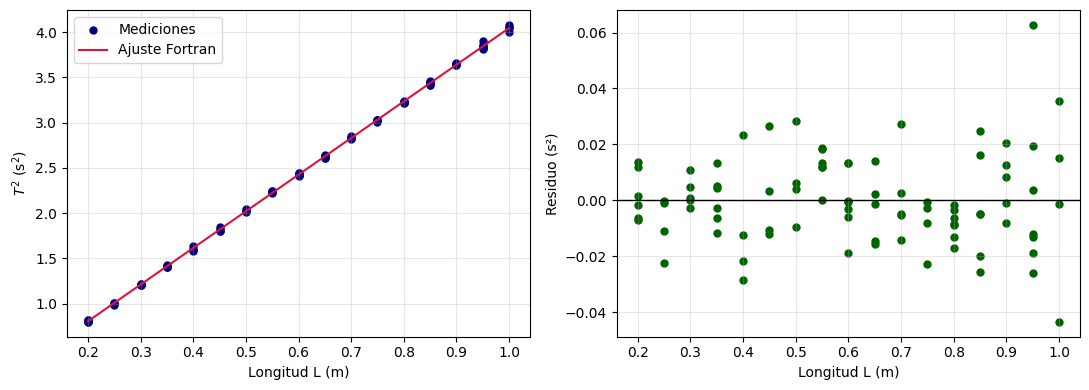

In [18]:
import numpy as np
import matplotlib.pyplot as plt

#Leer los datos limpios
datos = np.loadtxt("pendulo_limpio.dat")
longitud_m = datos[:, 1] / 100.0
numero_oscilaciones = datos[:, 3]
tiempo_total_s = datos[:, 4]

# Construcción de variables linealizadas
periodo_s = tiempo_total_s / numero_oscilaciones
x = longitud_m
y = periodo_s**2

# Leer los parámetros calculados por Fortran
resultados = np.loadtxt("resultados_ajuste.dat")
a = resultados[1]
b = resultados[2]

# Ajuste y residuos
orden = np.argsort(x)
y_ajustada = a*x + b
residuos = y - y_ajustada

# gráfica
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.scatter(x, y, s=25, color="navy", label="Mediciones")
ax1.plot(x[orden], y_ajustada[orden], color="crimson", label="Ajuste Fortran")
ax1.set_xlabel("Longitud L (m)")
ax1.set_ylabel(r"$T^2$ (s$^2$)")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.axhline(0.0, color="black", linewidth=1)
ax2.scatter(x, residuos, s=25, color="darkgreen")
ax2.set_xlabel("Longitud L (m)")
ax2.set_ylabel("Residuo (s²)")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ajuste_pendulo_y_residuos.png", dpi=200, bbox_inches="tight")
plt.show()